## Bài tập thực hành 1 - 2026
## Phân loại ảnh sử dụng Thuật toán KNN và các đặt trưng màu sắc
Link google colab: https://drive.google.com/file/d/1tB50MTQDShGBM-Cvnyeo8d612tanZQYr/view?usp=sharing

---
### Thông tin sinh viên
- **MSSV**: 24521901
- **Họ và tên**: Trần Quang Trường
---


### 0. Mô tả bài toán

Cho trước 1 tập dữ liệu HoaVietNam chứa 07 loài hoa:
- Cuc: Tên loài hoa Cúc
- Dao: Tên loài hoa Đào
- Ga: Tên loài hoa Mào Gà
- Lan: Tên loài hoa Phong lan
- Mai: Tên loài hoa Mai
- Sen: Tên loài hoa Sen
- Tho: Tên loài hoa Vạn thọ

Được tổ chức như sau:
- train: chứa 07 thư mục tương ứng với 07 loài hoa, mỗi thư mục có các ảnh *.jpg
- test: chứa 07 thư mục tương ứng với 07 loài hoa, mỗi thư mục có các ảnh *.jpg


---

#### 0.1 Đọc dữ liệu
Trước khi thực hiện yêu cầu bài tập, ta sẽ đọc tập dữ liệu train và test từ `HoaVietNam2026.zip`

Để truy cập tập dữ liệu, ta sẽ mount tới Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import các thư viện cần thiết


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans

Ta sẽ giải nén thư mục `HoaVietNam2026.zip` tại thư mục `MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/`.

In [ ]:
import zipfile
import shutil

source_zip = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/HoaVietNam2026.zip'
destination_dir = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/'

if os.path.exists(os.path.join(destination_dir, 'HoaVietNam2026')):
  shutil.rmtree(os.path.join(destination_dir, 'HoaVietNam2026'))

with zipfile.ZipFile(source_zip, 'r') as f:
    f.extractall(destination_dir)

print(f"Dữ liệu bao gồm các tập: {os.listdir(os.path.join(destination_dir, 'HoaVietNam2026'))}")

Dữ liệu bao gồm các tập: ['test', 'train']


Vì cấu trúc tập train và test là như nhau nên ta sẽ tạo một hàm để có thể extract dữ liệu từ thư mục sau khi giải nén.

In [ ]:
def load_images_from_folder(folder_dir):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder_dir))

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(folder_dir, class_name)
        if os.path.isdir(class_folder):
            for filename in os.listdir(class_folder):
                img_path = os.path.join(class_folder, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    images.append(img)
                    labels.append(label)

    return images, labels, class_names

In [ ]:
train_folder_dir  = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/HoaVietNam2026/train'
test_folder_dir   = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/HoaVietNam2026/test'

X_train, y_train, class_names = load_images_from_folder(train_folder_dir)
X_test, y_test, _ = load_images_from_folder(test_folder_dir)

y_train = np.array(y_train)
y_test = np.array(y_test)

print(f"Nhãn các loài hoa: {class_names}")
print(f"Tổng số ảnh trong tập train: {len(X_train)}")
print(f"Tổng số ảnh trong tập test: {len(X_test)}")

Nhãn các loài hoa: ['Cuc', 'Dao', 'Ga', 'Lan', 'Mai', 'Sen', 'Tho']
Tổng số ảnh trong tập train: 250
Tổng số ảnh trong tập test: 77


Để kiểm tra, ta một ảnh cho từng loại hoa trong tập train:


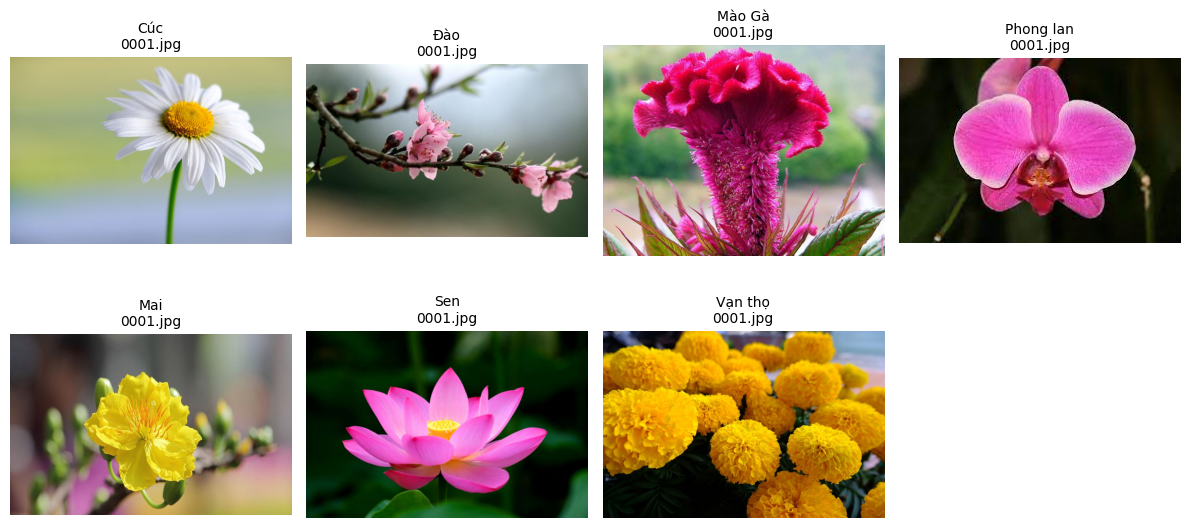

In [ ]:
from PIL import Image

train_dir = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/HoaVietNam2026/train'

class_names_dict = {
    "Cuc": "Cúc",
    "Dao": "Đào",
    "Ga": "Mào Gà",
    "Lan": "Phong lan",
    "Mai": "Mai",
    "Sen": "Sen",
    "Tho": "Vạn thọ"
}

plt.figure(figsize=(12, 6))

for i, folder in enumerate(class_names_dict.keys(), 1):
    class_dir = os.path.join(train_dir, folder)
    image_path = os.path.join(class_dir, os.listdir(class_dir)[0])

    if not image_path:
        continue

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(f"{class_names_dict[folder]}\n{os.path.basename(image_path)}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

---

### 1. Yêu cầu 1
Áp dụng Bộ phân lớp **KNeighborsClassifier** để thực hiện phân loại. Hãy xác định **giá trị của các tham số** sao cho Độ chính xác cao nhất:
- `n_neighbors`: 1 - 10
- `weights`: `{‘uniform’, ‘distance’}`
- `metric_options = ['braycurtis', 'canberra',
'correlation', 'cosine', 'euclidean',
'minkowski']`

Sử dụng đặc trưng về màu sắc:
- Histogram với 3 thành phần màu RGB
- Sử dụng 256 bin cho mỗi thành phần màu
- Tính histogram riêng từng thành phần

Đầu tiên, ta tạo hàm tính đặc trưng về màu sắc:

In [ ]:
def compute_histogram_feature(image, bins=256):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    feature_vector = []

    for i in range(3):
        hist = cv2.calcHist([image], [i], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        feature_vector.extend(hist)

    return np.array(feature_vector)

In [ ]:
# Tính đặc trưng cho các ảnh trong tập huấn luyện và tập kiểm tra
X_train_RGB = np.array([compute_histogram_feature(img, bins=256) for img in X_train])
X_test_RGB = np.array([compute_histogram_feature(img, bins=256) for img in X_test])


print(f"Kích thước tập train: {X_train_RGB.shape}, {y_train.shape}")
print(f"Kích thước tập test: {X_test_RGB.shape}, {y_test.shape}")

Kích thước tập train: (250, 768), (250,)
Kích thước tập test: (77, 768), (77,)


In [ ]:
from itertools import product

best_acc = 0
best_params = {}

n_neighbors = range(1, 11)
weights = ['uniform', 'distance']
metric_options = ['braycurtis', 'canberra', 'correlation', 'cosine', 'euclidean', 'minkowski']

for n_neighbor, weight, metric in product(n_neighbors, weights, metric_options):
    knn = KNeighborsClassifier(n_neighbors=n_neighbor, weights=weight, metric=metric)
    knn.fit(X_train_RGB, y_train)
    y_pred = knn.predict(X_test_RGB)

    acc = accuracy_score(y_test, y_pred)
    print(f"Testing: n_neighbors={n_neighbor},weights={weight}, metric={metric}, Accuracy={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_params = {'n_neighbors': n_neighbor, 'weights': weight, 'metric_options': metric}

print("\nTham số tối ưu:", best_params)
print(f"Độ chính xác cao nhất: {best_acc:.4f}")


Testing: n_neighbors=1,weights=uniform, metric=braycurtis, Accuracy=0.6234
Testing: n_neighbors=1,weights=uniform, metric=canberra, Accuracy=0.6494
Testing: n_neighbors=1,weights=uniform, metric=correlation, Accuracy=0.5844
Testing: n_neighbors=1,weights=uniform, metric=cosine, Accuracy=0.5714
Testing: n_neighbors=1,weights=uniform, metric=euclidean, Accuracy=0.5714
Testing: n_neighbors=1,weights=uniform, metric=minkowski, Accuracy=0.5714
Testing: n_neighbors=1,weights=distance, metric=braycurtis, Accuracy=0.6234
Testing: n_neighbors=1,weights=distance, metric=canberra, Accuracy=0.6494
Testing: n_neighbors=1,weights=distance, metric=correlation, Accuracy=0.5844
Testing: n_neighbors=1,weights=distance, metric=cosine, Accuracy=0.5714
Testing: n_neighbors=1,weights=distance, metric=euclidean, Accuracy=0.5714
Testing: n_neighbors=1,weights=distance, metric=minkowski, Accuracy=0.5714
Testing: n_neighbors=2,weights=uniform, metric=braycurtis, Accuracy=0.6234
Testing: n_neighbors=2,weights=un

$\Rightarrow$ Như vậy với tham số tối ưu `{'n_neighbors': 3, 'weights': 'distance', 'metric': 'braycurtis'}` cho ta độ chính xác cao nhất là $0.6623$

---

### 2. Yêu cầu 2
Từ các giá trị tham số tối ưu. Hãy thực nghiệm so sánh
độ chính xác khi sử dụng đặc trưng về màu sắc:
- Histogram với 3 thành phần màu HSV tương ứng 8x8x8
- Moment màu
- Màu chủ đạo


In [ ]:
#Histogram với 3 thành phần màu HSV tương ứng 8x8x8
def compute_histogram_feature_hsv(image, bins=8):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([image], [0, 1, 2], None, [bins, bins, bins], [0, 180, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return np.array(hist)

In [ ]:
# Đặc trưng Moment màu
def compute_moment_feature(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Chuyển sang RGB
    mean = np.mean(image, axis=(0, 1))
    std = np.std(image, axis=(0, 1))
    skewness = np.mean(((image - mean) / (std + 1e-6)) ** 3, axis=(0, 1))
    return np.concatenate([mean, std, skewness])

In [ ]:
# Đặc trưng Màu chủ đạo
def compute_dominant_color_feature(image, n_clusters=3, n_init=10):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixels = image.reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_clusters,n_init=n_init)
    kmeans.fit(pixels)
    return kmeans.cluster_centers_.flatten()

Ta sẽ khởi tạo mô hình với các tham số tối ưu tìm được ở Yêu cầu 1

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'],
                           weights=best_params['weights'],
                           metric=best_params['metric_options'])

#### 2.1 Độ chính xác khi sử dụng **Histogram với 3 thành phần màu HSV tương ứng 8x8x8**

In [ ]:
X_train_hsv8 = np.array([compute_histogram_feature_hsv(img) for img in X_train])
X_test_hsv8 = np.array([compute_histogram_feature_hsv(img) for img in X_test])

In [ ]:
best_knn.fit(X_train_hsv8, y_train)
y_pred_hsv8 = best_knn.predict(X_test_hsv8)

acc_hsv8 = accuracy_score(y_test, y_pred_hsv8)
print(f"Độ chính xác với Histogram HSV 8: {acc_hsv8:.4f}\n")
print(classification_report(y_test,y_pred_hsv8,digits=4))

Độ chính xác với Histogram HSV 8: 0.7403

              precision    recall  f1-score   support

           0     0.7500    0.9000    0.8182        10
           1     0.7500    0.7500    0.7500        12
           2     0.6875    0.7333    0.7097        15
           3     0.8000    0.4000    0.5333        10
           4     0.7692    1.0000    0.8696        10
           5     0.6667    0.6000    0.6316        10
           6     0.8000    0.8000    0.8000        10

    accuracy                         0.7403        77
   macro avg     0.7462    0.7405    0.7303        77
weighted avg     0.7425    0.7403    0.7295        77



$\Rightarrow$ Độ chính xác với Histogram HSV 8: 0.7403

#### 2.2 Độ chính xác khi sử dụng **Moment màu**

In [ ]:
X_train_moment = np.array([compute_moment_feature(img) for img in X_train])
X_test_moment = np.array([compute_moment_feature(img) for img in X_test])

In [ ]:
best_knn.fit(X_train_moment, y_train)
y_pred_moment = best_knn.predict(X_test_moment)

acc_moment = accuracy_score(y_test, y_pred_moment)
print(f"Độ chính xác với Moment màu: {acc_moment:.4f}\n")
print(classification_report(y_test,y_pred_moment,digits=4))

Độ chính xác với Moment màu: 0.5844

              precision    recall  f1-score   support

           0     0.7273    0.8000    0.7619        10
           1     0.6364    0.5833    0.6087        12
           2     0.5000    0.7333    0.5946        15
           3     0.5714    0.4000    0.4706        10
           4     0.7143    0.5000    0.5882        10
           5     0.4545    0.5000    0.4762        10
           6     0.6250    0.5000    0.5556        10

    accuracy                         0.5844        77
   macro avg     0.6041    0.5738    0.5794        77
weighted avg     0.5982    0.5844    0.5811        77



$\Rightarrow$ Độ chính xác với Moment màu: 0.5844


#### 2.3 Độ chính xác khi sử dụng **Màu chủ đạo**

In [ ]:
X_train_dominant = np.array([compute_dominant_color_feature(img) for img in X_train])
X_test_dominant = np.array([compute_dominant_color_feature(img) for img in X_test])

In [ ]:
best_knn.fit(X_train_dominant, y_train)
y_pred_dominant = best_knn.predict(X_test_dominant)
acc_dominant = accuracy_score(y_test, y_pred_dominant)
print(f"Độ chính xác với Màu chủ đạo: {acc_dominant:.4f}")
print(classification_report(y_test,y_pred_dominant,digits=4))

Độ chính xác với Màu chủ đạo: 0.4935
              precision    recall  f1-score   support

           0     0.5714    0.8000    0.6667        10
           1     0.5000    0.6667    0.5714        12
           2     0.6923    0.6000    0.6429        15
           3     0.4000    0.2000    0.2667        10
           4     0.2500    0.3000    0.2727        10
           5     0.8333    0.5000    0.6250        10
           6     0.2727    0.3000    0.2857        10

    accuracy                         0.4935        77
   macro avg     0.5028    0.4810    0.4759        77
weighted avg     0.5151    0.4935    0.4892        77



$\Rightarrow$ Độ chính xác với màu chủ đạo: 0.4935

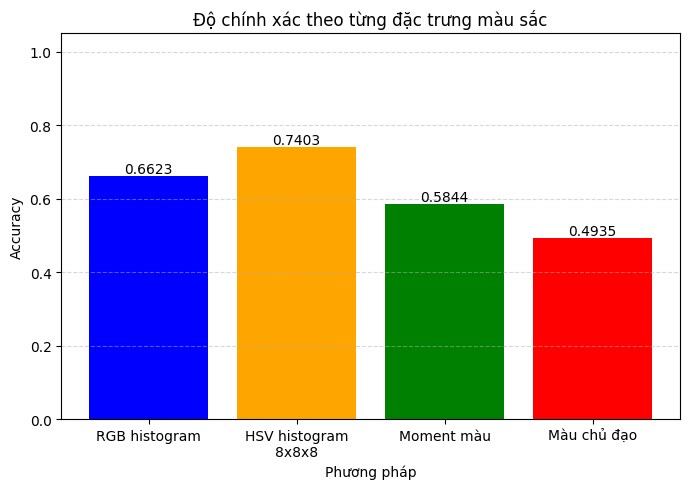

In [ ]:
import matplotlib.pyplot as plt

cases = [
    "RGB histogram",
    "HSV histogram\n8x8x8",
    "Moment màu",
    "Màu chủ đạo"
]

acc_values = [best_acc, acc_hsv8, acc_moment, acc_dominant]
colors = ["blue", "orange", "green", "red"]

plt.figure(figsize=(7, 5))
bars = plt.bar(cases, acc_values, color=colors)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.4f}",
        ha="center",
        va="bottom"
    )

plt.title("Độ chính xác theo từng đặc trưng màu sắc")
plt.xlabel("Phương pháp")
plt.ylabel("Accuracy")
plt.ylim(0, 1 + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

$\Rightarrow$ Như chúng ta thấy, mô hình với **Histogram với 3 thành phần màu HSV tương ứng 8x8x8** cho ta kết quả tốt nhất với acc 0.7403.

### 3. Yêu cầu 3
Sử dụng các giá trị tham tối ưu như trong yêu cầu 1.
- Giả sử gọi A là trường hợp sử dụng: Histogram với 3 thành phần màu
RGB
- Giả sử gọi B là trường hợp sử dụng: Histogram với 3 thành phần màu
HSV tương ứng 16x16x16

Hãy in ra danh sách các ảnh trong tập test mà trong trường hợp:
- A: sai nhưng B: đúng $\Rightarrow$ minh họa ưu điểm của B
- A: đúng nhưng B: sai $\Rightarrow$ minh họa ưu điểm của A
- A: sai và B: sai $\Rightarrow$ minh họa những mẫu khó

#### 3.1 Xây dựng mô hình A
Mô hình A là mô hình trong trường hợp sử dụng **Histogram với 3 thành phần màu RGB**.

In [ ]:
best_knn.fit(X_train_RGB, y_train)
y_pred_rgb = best_knn.predict(X_test_RGB)

acc_RGB = accuracy_score(y_test, y_pred_rgb)
print(f"Độ chính xác với Histogram RGB: {acc_RGB:.4f}")

Độ chính xác với Histogram RGB: 0.6623


#### 3.2 Xây dựng mô hình B
Mô hình B là mô hình trong trường hợp sử dụng **Histogram với 3 thành phần màu
HSV tương ứng 16x16x16**.

In [ ]:
X_train_hsv16 = np.array([compute_histogram_feature_hsv(img,16) for img in X_train])
X_test_hsv16 = np.array([compute_histogram_feature_hsv(img,16) for img in X_test])

In [ ]:
best_knn.fit(X_train_hsv16, y_train)
y_pred_hsv16 = best_knn.predict(X_test_hsv16)

acc_hsv16 = accuracy_score(y_test, y_pred_hsv16)
print(f"Độ chính xác với Histogram HSV 16x16x16: {acc_hsv16:.4f}")

Độ chính xác với Histogram HSV 16x16x16: 0.7922


#### 3.3 Chuẩn bị trước khi minh họa
Trước khi minh họa các trường hợp, ta cần chuẩn bị:


- Các trường hợp dự đoán đúng `correct_rgb`  và dự đoán sai `incorrect_rgb` cho mô hình A:

In [ ]:
correct_rgb = np.where(y_pred_rgb == y_test)[0]
incorrect_rgb = np.where(y_pred_rgb != y_test)[0]

- Các trường hợp dự đoán đúng `correct_hsv16` và dự đoán sai `incorrect_hsv16` cho mô hình B:

In [ ]:
correct_hsv16 = np.where(y_pred_hsv16 == y_test)[0]
incorrect_hsv16 = np.where(y_pred_hsv16 != y_test)[0]

- Ngoài ra, ta cũng nên chuẩn bị hàm plot ảnh:

In [ ]:
def show_images(images, title):
    if len(images) == 0:
        print(f"Không có ảnh nào thỏa điều kiện: {title}")
        return

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(images[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(cv2.cvtColor(X_test[idx], cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"RGB: {class_names[y_pred_rgb[idx]]}\nHSV: {class_names[y_pred_hsv16[idx]]}\nThực tế: {class_names[y_test[idx]]}", fontsize=10)

    plt.suptitle(title, fontsize=10)
    plt.show()

**3.3.1 Minh họa trường hợp A sai B đúng**

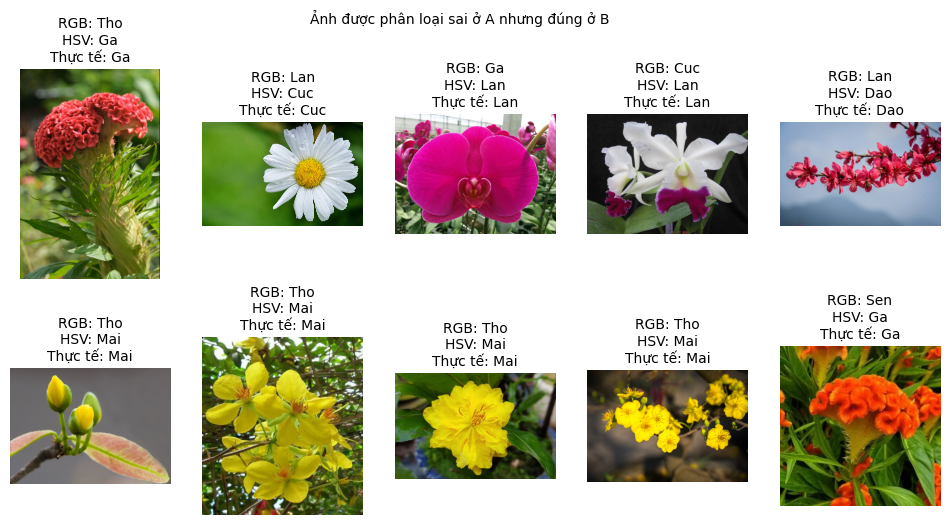

In [ ]:
fixed_by_hsv_1 = list(set(incorrect_rgb) & set(correct_hsv16))
show_images(fixed_by_hsv_1, "Ảnh được phân loại sai ở A nhưng đúng ở B")

**3.3.2 Minh họa trường hợp A đúng B sai**

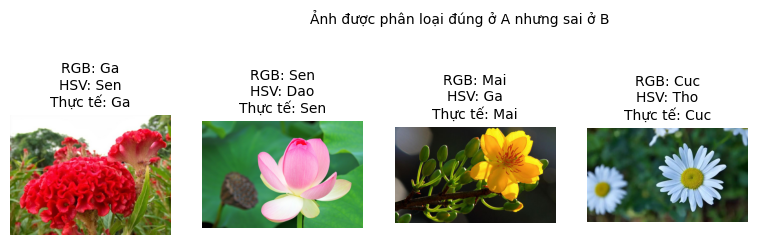

In [ ]:
fixed_by_hsv_2 = list(set(correct_rgb) & set(incorrect_hsv16))
show_images(fixed_by_hsv_2, "Ảnh được phân loại đúng ở A nhưng sai ở B")

**3.3.3 Minh họa trường hợp cả 2 đều sai**

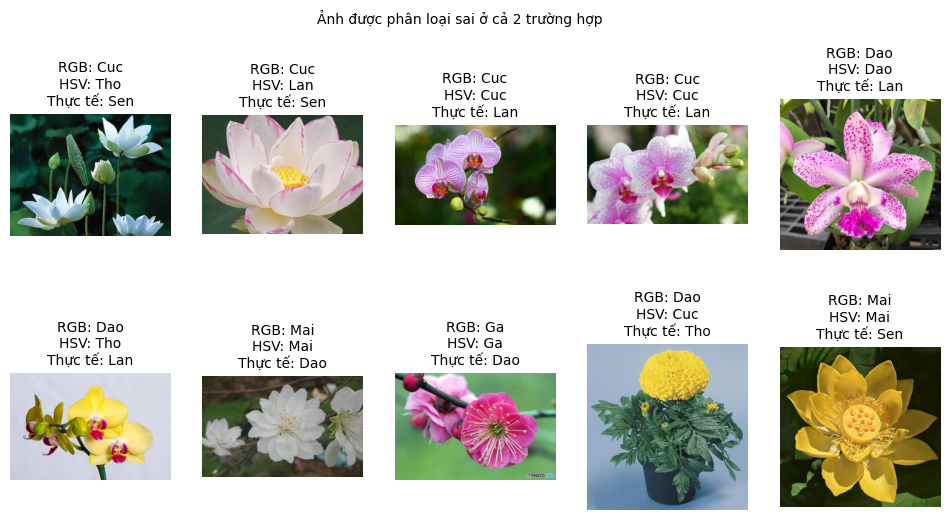

In [ ]:
fixed_by_hsv_3 = list(set(incorrect_rgb) & set(incorrect_hsv16))
show_images(fixed_by_hsv_3, "Ảnh được phân loại sai ở cả 2 trường hợp")